# Capstone Phase 3A — Replicating the Base Paper
## Maazallahi, Asadpour & Bazmi (2025), *Advancing emotion recognition in social media*, IP&M 62, 103974

**M A Kaushik · CH.SC.U4CSE24123 · PSID 181**

This notebook re-implements the paper's method as written and reproduces its experiments one by one:

| Paper | What it reports | Section here |
|---|---|---|
| Table 1 | GoEmotions / Friends / TEC sizes | 1 |
| §2.1, Table 4 | Agreement (compliance) between DistilRoBERTa and RoBERTa-large | 2 |
| §2.2.1–2.2.6 | Tweet–phrase–emotion graph, TextRank, features, thresholds | 3 |
| §2.2.7, Eq. 1–5 | Heterogeneous GNN (GraphSAGE-style conv + mean / semantic-attention aggregation) | 4 |
| Table 3, Fig. 5 | Mean vs attention aggregation; hidden size × number of layers | 5.2–5.3 |
| Tables 5–6, Figs. 6–8 | Accuracy / F1 / precision / recall on compliance, non-compliance and total; HGNN-Max / HGNN-Min | 5.4–5.5 |
| Table 7 | Paired t-tests vs. baselines | 5.6 |

Following the paper's experimental setup (§3.4.2, Table 4): the **compliance split** uses DistilRoBERTa vs RoBERTa-large, the **tweet features** are the **DistilRoBERTa scores**, and the Friends-specific **DistilRoBERTa-v2** is a third baseline. Metrics are **weighted averages**: in the paper's Table 6, recall equals accuracy in every row, which only happens with weighted averaging.

In [1]:
import os, sys, re, json, html, random, zipfile, io, urllib.request, warnings, subprocess, itertools, time
from collections import Counter, defaultdict

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch_geometric'], check=True)
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/Capstone Project'   # change if the folder is elsewhere in Drive
else:
    PROJECT_DIR = os.getcwd()

RAW_DIR = os.path.join(PROJECT_DIR, 'data', 'raw')
PROC_DIR = os.path.join(PROJECT_DIR, 'data', 'processed')
RES_DIR = os.path.join(PROJECT_DIR, 'results', 'replication')
for d in (RAW_DIR, PROC_DIR, RES_DIR):
    os.makedirs(d, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import scipy.sparse as sp
from scipy import stats
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.utils import scatter
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers.utils import logging as hf_logging
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()
pd.set_option('display.width', 200)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Project dir:', PROJECT_DIR)
print('Device     :', DEVICE, torch.cuda.get_device_name(0) if DEVICE == 'cuda' else '')

C:\Users\kaush\venvs\capstone\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Project dir: C:\Users\kaush\OneDrive\ドキュメント\College\ML\Capstone Project
Device     : cuda NVIDIA GeForce RTX 2060


### Configuration
The paper does not report the learning rate, epochs, attention size, or the exact values in its hyperparameter grid. Where it is silent, this notebook uses the defaults of the PyTorch Geometric / DeepSnap heterogeneous-GNN reference implementation, which uses the same Eq. 1–5 and the same libraries the paper names (§3.5). The grid covers what the paper says it searched: hidden size, number of attention layers, mean vs attention aggregation, and the two ways of handling non-agreed tweets (§2.2.3).

In [2]:
CFG = dict(
    lms={'distil': 'j-hartmann/emotion-english-distilroberta-base',
         'roberta': 'j-hartmann/emotion-english-roberta-large',
         'distil_v2': 'michellejieli/emotion_text_classifier'},
    labels=['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise'],
    batch_size=64, max_len=128,
    top_k_phrases=4, textrank_window=3,          # TextRank
    edge_mean=0.5, edge_std=0.1,                 # phrase→emotion thresholds (§2.2.5)
    grid=dict(agg=['mean', 'attention'], hidden=[32, 64, 128, 300, 512], layers=[1, 2, 3],
              nonagreed=['scores', 'zero']),
    attn_size=32, lr=3e-3, weight_decay=1e-5, epochs=300, patience=30, val_frac=0.1,
    n_seeds=10, seed=42,
)
LABELS = CFG['labels']; L2I = {l: i for i, l in enumerate(LABELS)}; N_CLS = len(LABELS)
COLS = {m: [f'{m}_{l}' for l in LABELS] for m in CFG['lms']}
NICE = {'roberta': 'RoBERTa-large', 'distil': 'DistilRoBERTa', 'distil_v2': 'DistilRoBERTa-v2'}

def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed(CFG['seed'])

### The paper's reported numbers (used for side-by-side comparison)

In [3]:
_cols = ['dataset', 'model'] + [f'{m}_{s}' for m in ('acc', 'f1', 'precision', 'recall') for s in ('C', 'NC', 'T')]
PAPER = pd.DataFrame([   # Tables 5 and 6  (C = compliance, NC = non-compliance, T = total)
    ('GoEmotions', 'RoBERTa-large',    .731, .370, .636, .753, .434, .670, .819, .683, .778, .731, .370, .636),
    ('GoEmotions', 'DistilRoBERTa',    .731, .382, .639, .753, .454, .675, .819, .636, .772, .731, .382, .639),
    ('GoEmotions', 'DistilRoBERTa-v2', .711, .551, .669, .723, .589, .686, .745, .648, .717, .711, .551, .669),
    ('GoEmotions', 'HGNN-Max',         .720, .530, .671, .742, .568, .697, .796, .620, .751, .720, .530, .671),
    ('GoEmotions', 'HGNN-Min',         .758, .677, .737, .766, .624, .738, .787, .636, .752, .758, .677, .737),
    ('Friends',    'RoBERTa-large',    .703, .458, .630, .714, .491, .647, .761, .603, .712, .703, .458, .630),
    ('Friends',    'DistilRoBERTa',    .703, .287, .579, .714, .337, .605, .761, .508, .691, .703, .287, .579),
    ('Friends',    'DistilRoBERTa-v2', .878, .845, .868, .878, .843, .867, .878, .845, .868, .878, .845, .868),
    ('Friends',    'HGNN-Max',         .652, .258, .535, .674, .303, .578, .730, .398, .657, .652, .258, .535),
    ('Friends',    'HGNN-Min',         .550, .585, .561, .406, .433, .416, .423, .343, .435, .550, .585, .561),
    ('TEC',        'RoBERTa-large',    .451, .308, .401, .482, .337, .430, .534, .402, .484, .451, .308, .401),
    ('TEC',        'DistilRoBERTa',    .451, .171, .353, .482, .199, .391, .534, .288, .463, .451, .171, .353),
    ('TEC',        'DistilRoBERTa-v2', .353, .187, .295, .392, .221, .336, .480, .332, .438, .353, .187, .295),
    ('TEC',        'HGNN-Max',         .438, .255, .374, .471, .266, .408, .524, .370, .480, .438, .255, .374),
    ('TEC',        'HGNN-Min',         .480, .354, .436, .491, .345, .443, .512, .348, .454, .480, .354, .436),
], columns=_cols)
PAPER_T1 = {'GoEmotions': dict(anger=1798, disgust=1013, fear=650, joy=3256, neutral=22301, sadness=1852, surprise=1421),
            'Friends': dict(anger=759, disgust=331, fear=246, joy=1710, neutral=6530, sadness=498, surprise=1657),
            'TEC': dict(anger=1555, disgust=761, fear=2814, joy=8239, neutral=0, sadness=3830, surprise=3848)}
PAPER_T4 = {'GoEmotions': (23836, 8455), 'Friends': (8245, 3486), 'TEC': (13692, 7355)}
PAPER_T3 = {'HGNN (mean)': (0.50, 0.12), 'HGNN (attention)': (0.56, 0.14), 'DistilRoBERTa': (0.45, 0), 'RoBERTa-large': (0.43, 0)}
PAPER_T7 = pd.DataFrame([('acc', 'GoEmotions', 4.73, .0004), ('acc', 'Friends', 1.42, .0863), ('acc', 'TEC', 5.87, .0001),
                         ('f1', 'GoEmotions', 3.45, .0015), ('f1', 'Friends', 1.26, .1047), ('f1', 'TEC', 4.98, .0003),
                         ('recall', 'GoEmotions', 3.98, .0008), ('recall', 'Friends', 1.34, .0972), ('recall', 'TEC', 5.32, .0002)],
                        columns=['metric', 'dataset', 't (paper)', 'p (paper)'])

## 1. Datasets (paper Table 1)
| Dataset | Source | Notes |
|---|---|---|
| **GoEmotions** | raw rater-level release (58k Reddit comments) | The paper's subset (32,291 posts, copied from the Hartmann model card) is not described. The closest reconstruction found: comments where **exactly one of the 7 Ekman label names** was chosen by at least one rater. This gives 31,621 posts, within 2% of the paper overall and within 10% for every class. |
| **Friends** | EmotionLines (Chen et al., 2018), official EmotionX release | All utterances except the `non-neutral` class: **11,731**, identical to Table 1. |
| **TEC** | Twitter Emotion Corpus (Mohammad, 2012) | 21,051 tweets vs 21,047 in the paper. The corpus itself lists a few multi-label tweets twice; all are kept. Not seen by any of the language models. |

In [4]:
GO_FULL = [os.path.join(RAW_DIR, 'goemotions_full', f'goemotions_{i}.csv') for i in (1, 2, 3)]
FRIENDS_PATH = os.path.join(RAW_DIR, 'friends_emotionlines.json')
TEC_PATH = os.path.join(RAW_DIR, 'tec_tweets.txt')

def _fetch(url):
    with urllib.request.urlopen(url) as r:
        return r.read()

os.makedirs(os.path.dirname(GO_FULL[0]), exist_ok=True)
for i, p in enumerate(GO_FULL, 1):
    if not os.path.exists(p):
        open(p, 'wb').write(_fetch(f'https://storage.googleapis.com/gresearch/goemotions/data/full_dataset/goemotions_{i}.csv'))
if not os.path.exists(FRIENDS_PATH):
    z = zipfile.ZipFile(io.BytesIO(_fetch('https://raw.githubusercontent.com/bshmueli/EmotionX-2019/main/2019_Train_Friends.zip')))
    open(FRIENDS_PATH, 'wb').write(z.read('Friends/friends.json'))
if not os.path.exists(TEC_PATH):
    z = zipfile.ZipFile(io.BytesIO(_fetch('http://saifmohammad.com/WebDocs/Jan9-2012-tweets-clean.txt.zip')))
    open(TEC_PATH, 'wb').write(z.read([n for n in z.namelist() if n.endswith('.txt') and not n.startswith('__MACOSX')][0]))

# GoEmotions: per comment, the set of Ekman-named labels chosen by >= 1 rater; keep comments with exactly one
raw = pd.concat([pd.read_csv(p) for p in GO_FULL], ignore_index=True)
votes = raw.groupby('id')[LABELS].sum() >= 1
one = votes[votes.sum(axis=1) == 1]
go = pd.DataFrame({'id': one.index, 'gold': one.idxmax(axis=1).values})
go['text'] = go['id'].map(raw.drop_duplicates('id').set_index('id')['text'])
del raw

# Friends (EmotionLines): drop 'non-neutral'; repair Windows-1252 characters (e.g. \x92 apostrophes)
def fix_cp1252(s):
    try:
        return s.encode('latin-1').decode('cp1252')
    except (UnicodeEncodeError, UnicodeDecodeError):
        return s.replace('\x92', "'")
fr = [l for dia in json.load(open(FRIENDS_PATH, encoding='utf-8')) for l in dia]
friends = pd.DataFrame({'text': [fix_cp1252(l['utterance']) for l in fr], 'gold': [l['emotion'] for l in fr]})
friends = friends[friends['gold'] != 'non-neutral'].reset_index(drop=True)

# TEC
rows = []
for line in open(TEC_PATH, encoding='utf-8', errors='ignore'):
    line = line.rstrip('\n')
    if '\t:: ' in line:
        left, lab = line.rsplit('\t:: ', 1)
        parts = left.split('\t', 1)
        rows.append((parts[1] if len(parts) > 1 else '', lab.strip()))
tec = pd.DataFrame(rows, columns=['text', 'gold'])

DATA = {'GoEmotions': go[['text', 'gold']], 'Friends': friends, 'TEC': tec}
t1 = pd.DataFrame({f'{n} (ours)': d['gold'].value_counts().reindex(LABELS).fillna(0).astype(int) for n, d in DATA.items()})
for n in DATA:
    t1.insert(list(t1.columns).index(f'{n} (ours)') + 1, f'{n} (paper)', pd.Series(PAPER_T1[n]))
t1.loc['# rows'] = t1.sum()
t1.to_csv(os.path.join(RES_DIR, 'table1_datasets.csv'))
t1

,GoEmotions (ours),GoEmotions (paper),Friends (ours),Friends (paper),TEC (ours),TEC (paper)
gold,,,,,,
anger,1665,1798,759,759,1555,1555
disgust,921,1013,331,331,761,761
fear,587,650,246,246,2816,2814
joy,3208,3256,1710,1710,8240,8239
neutral,22152,22301,6530,6530,0,0
sadness,1745,1852,498,498,3830,3830
surprise,1343,1421,1657,1657,3849,3848
# rows,31621,32291,11731,11731,21051,21047


### Preprocessing (§3.3)
Noise removal (URLs, @mentions, GoEmotions placeholders such as `[NAME]`, HTML entities, the `#` sign, control characters) and whitespace normalisation. Punctuation and emojis stay, because the fine-tuned models use them as cues.

In [5]:
def clean_text(t):
    t = html.unescape(str(t))
    t = re.sub(r'https?://\S+|www\.\S+', ' ', t)
    t = re.sub(r'@\w+', ' ', t)
    t = re.sub(r'\[(NAME|RELIGION)\]', ' ', t)
    t = t.replace('#', ' ')
    t = re.sub(r'[\x00-\x1f\x7f-\x9f]', ' ', t)
    return re.sub(r'\s+', ' ', t).strip()

for n, d in DATA.items():
    d['clean'] = d['text'].map(clean_text)
    d.loc[d['clean'] == '', 'clean'] = '.'       # keep every post (empty utterances such as '...' in Friends)
    print(f'{n:10s} {len(d):6,d} posts')

GoEmotions 31,621 posts
Friends    11,731 posts


TEC        21,051 posts


## 2. Phase A: fine-tuned language models and the compliance split (§2.1, Table 4)
Each post is scored by DistilRoBERTa, RoBERTa-large and the Friends-specific DistilRoBERTa-v2. Compliance is defined by **DistilRoBERTa vs RoBERTa-large**, as in Table 4. Scores are cached in `data/processed/`.

In [6]:
def score_texts(model_name, texts):
    tok = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name).to(DEVICE).eval()
    if DEVICE == 'cuda':
        model = model.half()
    id2label = {int(k): v.lower() for k, v in model.config.id2label.items()}
    order = [next(k for k, v in id2label.items() if v == lab) for lab in LABELS]
    idx = np.argsort([len(t) for t in texts])
    out = np.zeros((len(texts), N_CLS), dtype=np.float32)
    with torch.inference_mode():
        for s in range(0, len(texts), CFG['batch_size']):
            b = idx[s:s + CFG['batch_size']]
            enc = tok([texts[i] for i in b], padding=True, truncation=True, max_length=CFG['max_len'],
                      return_tensors='pt').to(DEVICE)
            out[b] = model(**enc).logits.float().softmax(-1).cpu().numpy()[:, order]
    del model
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()
    return out

def scored(name, d):
    path = os.path.join(PROC_DIR, f'{name.lower()}_scored.csv')
    if os.path.exists(path):
        c = pd.read_csv(path, keep_default_na=False)
        if len(c) == len(d) and (c['clean'].values == d['clean'].values).all():
            print(f'{name}: loaded cached scores'); return c
    d = d.copy()
    for m, hf in CFG['lms'].items():
        print(f'{name}: scoring {len(d):,} posts with {hf}')
        d[COLS[m]] = score_texts(hf, d['clean'].tolist())
    d.to_csv(path, index=False)
    return d

DATA = {n: scored(n, d) for n, d in DATA.items()}

GoEmotions: loaded cached scores
Friends: loaded cached scores


TEC: loaded cached scores


In [7]:
rows = []
for n, d in DATA.items():
    la, lb = d[COLS['distil']].values.argmax(1), d[COLS['roberta']].values.argmax(1)
    comp = la == lb
    rows.append({'dataset': n, 'compliance (ours)': comp.sum(), 'compliance (paper)': PAPER_T4[n][0],
                 'non-compliance (ours)': (~comp).sum(), 'non-compliance (paper)': PAPER_T4[n][1],
                 'compliance % (ours)': round(100 * comp.mean(), 1),
                 'compliance % (paper)': round(100 * PAPER_T4[n][0] / sum(PAPER_T4[n]), 1)})
t4 = pd.DataFrame(rows).set_index('dataset')
t4.to_csv(os.path.join(RES_DIR, 'table4_compliance.csv'))
t4

,compliance (ours),compliance (paper),non-compliance (ours),non-compliance (paper),compliance % (ours),compliance % (paper)
dataset,,,,,,
GoEmotions,22976,23836,8645,8455,72.7,73.8
Friends,8463,8245,3268,3486,72.1,70.3
TEC,14118,13692,6933,7355,67.1,65.1


## 3. Heterogeneous graph G = {Nodes: (T, P, E), Edges: (T⇔P, P⇔E)} (§2.2.1–2.2.6)
* **Phrases (§2.2.2):** TextRank over each post (co-occurrence window 3, PageRank, top-k keywords; adjacent keywords are merged into phrases). Every distinct phrase becomes a node.
* **Tweet features (§2.2.3):** DistilRoBERTa scores (7-d). Non-agreed tweets either keep their scores (`scores`) or get a zero vector (`zero`). The paper tests both, so both are in the grid.
* **Phrase features (§2.2.4):** mean ⊕ std of the features of the agreed tweets containing the phrase (14-d). The vector is zero if no agreed tweet contains it.
* **Phrase → emotion edges (§2.2.5):** added when the phrase's mean score for that emotion is > 0.5 and its std is < 0.1.
* **Emotion features (§2.2.6):** one-hot vectors (a 7 × 7 identity matrix).
* The model is trained on agreed tweets, with the label both models agreed on as the target. 10% of agreed tweets are held out for early stopping. Gold labels are only used for evaluation.

In [8]:
STOP = set(ENGLISH_STOP_WORDS) | {"i'm", "it's", "that's", "you're", "i've", "i'll", "he's", "she's", "they're", "we're",
                                  "there's", "what's", "let's", "i'd", "you'll", "you've", "we've", "they've",
                                  'im', 'dont', 'thats', 'youre'}
TOKEN_RE = re.compile(r"[a-z][a-z']+")

def textrank_phrases(text, top_k=CFG['top_k_phrases'], window=CFG['textrank_window']):
    words = [w.strip("'") for w in TOKEN_RE.findall(text.lower())]
    cands = [w for w in words if w not in STOP and len(w) > 2]
    if not cands:
        return []
    g = nx.Graph(); g.add_nodes_from(cands)
    for i in range(len(cands)):
        for j in range(i + 1, min(i + window, len(cands))):
            if cands[i] != cands[j]:
                g.add_edge(cands[i], cands[j])
    rank = nx.pagerank(g) if g.number_of_edges() else {w: 1.0 for w in g}
    top = set(sorted(rank, key=rank.get, reverse=True)[:top_k])
    phrases, run = set(top), []
    for i, w in enumerate(words):
        if w in top and (not run or i == run[-1][0] + 1):
            run.append((i, w))
        else:
            if len(run) > 1: phrases.add(' '.join(x for _, x in run))
            run = [(i, w)] if w in top else []
    if len(run) > 1: phrases.add(' '.join(x for _, x in run))
    return sorted(phrases)


def build_graph(name, d):
    S = d[COLS['distil']].values.astype(np.float32)
    la, lb = S.argmax(1), d[COLS['roberta']].values.argmax(1)
    comp = la == lb
    phrases = d['clean'].map(textrank_phrases)
    vocab = sorted({p for ps in phrases for p in ps})
    p2i = {p: i for i, p in enumerate(vocab)}
    tp = np.array([(t, p2i[p]) for t, ps in enumerate(phrases) for p in ps]).T
    M = sp.csr_matrix((np.ones(tp.shape[1], np.float32), (tp[0], tp[1])), shape=(len(d), len(vocab)))
    Mc = sp.diags(comp.astype(np.float32)) @ M
    support = np.asarray(Mc.sum(0)).ravel()
    denom = np.maximum(support, 1)[:, None]
    mean = np.asarray(Mc.T @ S) / denom
    std = np.sqrt(np.clip(np.asarray(Mc.T @ S ** 2) / denom - mean ** 2, 0, None))
    phrase_x = np.hstack([mean, std]).astype(np.float32)                 # zero when no agreed tweet
    pe = (mean > CFG['edge_mean']) & (std < CFG['edge_std']) & (support[:, None] > 0)
    pe_idx = np.array(np.nonzero(pe))

    cand = np.where(comp)[0]
    try:
        tr, va = train_test_split(cand, test_size=CFG['val_frac'], random_state=CFG['seed'], stratify=la[cand])
    except ValueError:
        tr, va = train_test_split(cand, test_size=CFG['val_frac'], random_state=CFG['seed'])
    t = lambda a, dt=torch.float: torch.tensor(a, dtype=dt, device=DEVICE)
    X_zero = S.copy(); X_zero[~comp] = 0
    g = dict(name=name, d=d, phrases=phrases, vocab=vocab, M=M, pe=pe, S=S, la=la, lb=lb, comp=comp,
             gold=d['gold'].map(L2I).values, v2=d[COLS['distil_v2']].values.argmax(1),
             x={'scores': t(S), 'zero': t(X_zero)}, x_phrase=t(phrase_x), x_emotion=torch.eye(N_CLS, device=DEVICE),
             ei={('tweet', 'has', 'phrase'): t(tp, torch.long),
                 ('phrase', 'in', 'tweet'): t(tp[::-1].copy(), torch.long),
                 ('phrase', 'signals', 'emotion'): t(pe_idx, torch.long),
                 ('emotion', 'signalled_by', 'phrase'): t(pe_idx[::-1].copy(), torch.long)},
             y=t(la, torch.long), train_idx=t(tr, torch.long), val_idx=t(va, torch.long))
    print(f'{name:10s} tweets={len(d):6,d}  phrases={len(vocab):6,d}  emotions={N_CLS}  T-P edges={tp.shape[1]:7,d}  '
          f'P-E edges={pe_idx.shape[1]:6,d}  phrases w/o agreed tweet={int((support == 0).sum()):,}  '
          f'train/val={len(tr):,}/{len(va):,}')
    return g

GRAPHS = {n: build_graph(n, d) for n, d in DATA.items()}

GoEmotions tweets=31,621  phrases=38,746  emotions=7  T-P edges=132,152  P-E edges=21,546  phrases w/o agreed tweet=8,736  train/val=20,678/2,298


Friends    tweets=11,731  phrases= 9,439  emotions=7  T-P edges= 33,292  P-E edges= 4,775  phrases w/o agreed tweet=2,204  train/val=7,616/847


TEC        tweets=21,051  phrases=32,838  emotions=7  T-P edges=102,969  P-E edges=16,165  phrases w/o agreed tweet=9,361  train/val=12,706/1,412


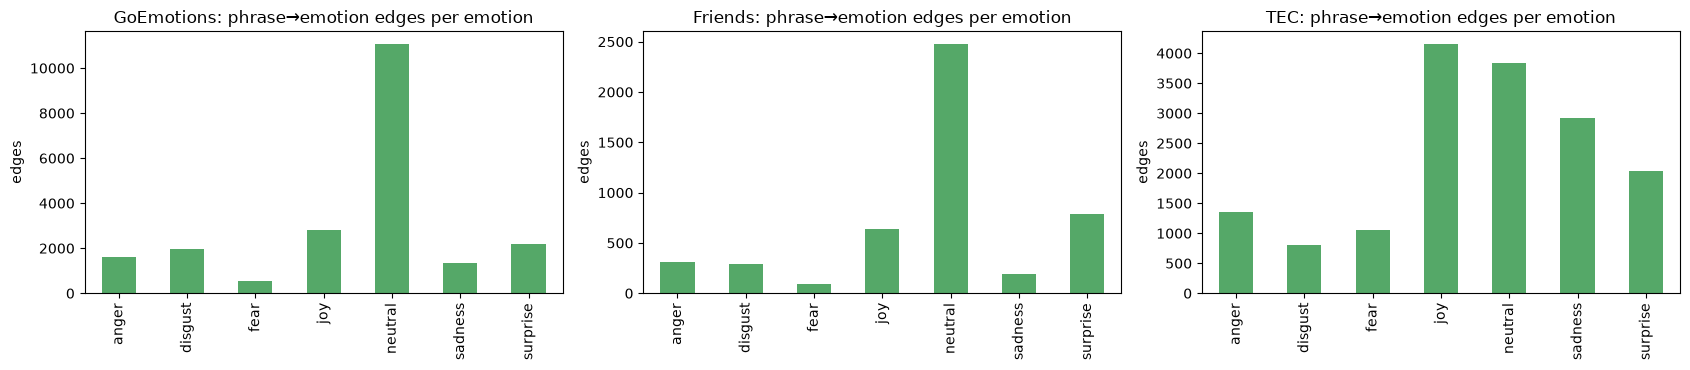

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 3.8))
for ax, (n, g) in zip(axes, GRAPHS.items()):
    pd.Series(g['pe'].sum(0), index=LABELS).plot.bar(ax=ax, color='#55A868')
    ax.set_title(f'{n}: phrase→emotion edges per emotion'); ax.set_ylabel('edges')
plt.tight_layout(); plt.savefig(os.path.join(RES_DIR, 'fig_phrase_emotion_edges.png'), dpi=150); plt.show()

## 4. Heterogeneous GNN (§2.2.7)
**Eq. 1** (per message type $m$): $h_u^{(l)}[m] = W^{(l)}[m]\cdot\text{CONCAT}\big(W_U^{(l)}[m]\,h_u^{(l-1)},\; W_T^{(l)}[m]\cdot\text{AGG}\{h_t^{(l-1)}, t\in N_m(u)\}\big)$, with **Eq. 2** mean AGG.
Message types: T→P, P→T, P→E and E→P (the edges are bidirectional, T⇔P and P⇔E).

Message-type aggregation: **Eq. 3** is a plain mean. **Eq. 4–5** is semantic attention:
$e_m = \frac{1}{|V_d|}\sum_v q^\top\tanh(W h_v[m] + b)$, $\alpha_m = \text{softmax}(e_m)$, $h_v = \sum_m \alpha_m h_v[m]$.

Each heterogeneous layer is followed by BatchNorm and ReLU. A final linear layer per node type outputs the emotion scores (Fig. 4).

In [10]:
class HeteroGNNConv(nn.Module):                       # Eq. (1)-(2)
    def __init__(self, in_src, in_dst, out):
        super().__init__()
        self.lin_dst = nn.Linear(in_dst, out)         # W_U[m]
        self.lin_src = nn.Linear(in_src, out)         # W_T[m]
        self.lin_update = nn.Linear(2 * out, out)     # W[m]

    def forward(self, x_src, x_dst, ei):
        agg = scatter(x_src[ei[0]], ei[1], dim=0, dim_size=x_dst.size(0), reduce='mean')
        return self.lin_update(torch.cat([self.lin_dst(x_dst), self.lin_src(agg)], dim=-1))


class HeteroLayer(nn.Module):                          # Eq. (3) or Eq. (4)-(5)
    def __init__(self, in_dims, out, edge_types, agg, attn_size):
        super().__init__()
        self.edge_types, self.agg = edge_types, agg
        self.convs = nn.ModuleDict({'__'.join(et): HeteroGNNConv(in_dims[et[0]], in_dims[et[2]], out) for et in edge_types})
        if agg == 'attention':
            self.attn = nn.ModuleDict({t: nn.Sequential(nn.Linear(out, attn_size), nn.Tanh(), nn.Linear(attn_size, 1, bias=False))
                                       for t in {et[2] for et in edge_types}})
        self.alpha = {}

    def forward(self, x, ei):
        msgs, names = defaultdict(list), defaultdict(list)
        for et in self.edge_types:
            msgs[et[2]].append(self.convs['__'.join(et)](x[et[0]], x[et[2]], ei[et]))
            names[et[2]].append(f'{et[0]}→{et[2]}')
        out = {}
        for t, hs in msgs.items():
            H = torch.stack(hs, dim=1)                                    # [N, M, d]
            if self.agg == 'attention' and len(hs) > 1:
                alpha = torch.softmax(self.attn[t](H).mean(0), dim=0)      # [M, 1]
                self.alpha[t] = (names[t], alpha.detach().view(-1))
                out[t] = (alpha.unsqueeze(0) * H).sum(1)
            else:
                out[t] = H.mean(1)
        return out


class HGNN(nn.Module):
    def __init__(self, in_dims, hidden, n_layers, edge_types, agg, attn_size=32):
        super().__init__()
        dims = [in_dims] + [{k: hidden for k in in_dims}] * n_layers
        self.layers = nn.ModuleList([HeteroLayer(dims[i], hidden, edge_types, agg, attn_size) for i in range(n_layers)])
        self.bns = nn.ModuleList([nn.ModuleDict({k: nn.BatchNorm1d(hidden) for k in in_dims}) for _ in range(n_layers)])
        self.post = nn.ModuleDict({k: nn.Linear(hidden, N_CLS) for k in in_dims})   # linear emotion scores per node type

    def forward(self, x, ei):
        for layer, bn in zip(self.layers, self.bns):
            x = {k: F.relu(bn[k](v)) for k, v in layer(x, ei).items()}
        return {k: self.post[k](v) for k, v in x.items()}


def train_hgnn(g, agg, hidden, layers, nonagreed, seed=CFG['seed']):
    set_seed(seed)
    x = {'tweet': g['x'][nonagreed], 'phrase': g['x_phrase'], 'emotion': g['x_emotion']}
    ets = list(g['ei'].keys())
    model = HGNN({k: v.size(1) for k, v in x.items()}, hidden, layers, ets, agg, CFG['attn_size']).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    tr, va, y = g['train_idx'], g['val_idx'], g['y']
    best, best_state, wait = float('inf'), None, 0
    for ep in range(CFG['epochs']):
        model.train(); opt.zero_grad()
        loss = F.cross_entropy(model(x, g['ei'])['tweet'][tr], y[tr])
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vloss = F.cross_entropy(model(x, g['ei'])['tweet'][va], y[va]).item()
        if vloss < best - 1e-4:
            best, wait, best_ep = vloss, 0, ep
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= CFG['patience']:
                break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        probs = model(x, g['ei'])['tweet'].softmax(-1).cpu().numpy()
    return model, probs, best, best_ep

## 5. Experiments
### 5.1 Metrics
Weighted accuracy / F1 / precision / recall against the **gold** labels on three sets: the compliance set (C), the non-compliance set (NC) and the total (T), as in Tables 5–6. **Similarity to RoBERTa** is the share of posts where a model's label equals RoBERTa-large's label. This is the quantity behind the paper's HGNN-Max and HGNN-Min.

The table also includes a reference rule **that is not in the paper**: keep the label where the two models agree, and answer *neutral* where they disagree. It needs no training and no gold labels. It shows how much of any gain on the non-compliance set comes simply from the class balance of that set.

In [11]:
def evaluate(g, pred):
    out = {}
    for s, m in (('C', g['comp']), ('NC', ~g['comp']), ('T', np.ones_like(g['comp']))):
        p, r, f, _ = precision_recall_fscore_support(g['gold'][m], pred[m], average='weighted', zero_division=0)
        out.update({f'acc_{s}': accuracy_score(g['gold'][m], pred[m]), f'f1_{s}': f, f'precision_{s}': p, f'recall_{s}': r})
    out['sim_roberta'] = (pred == g['lb']).mean()
    return out

base = pd.DataFrame([dict(dataset=n, model=NICE[m], **evaluate(g, g[k]))
                     for n, g in GRAPHS.items() for m, k in (('roberta', 'lb'), ('distil', 'la'), ('distil_v2', 'v2'))])
# Reference rule (not in the paper, no training, no gold labels): keep the agreed label, answer 'neutral' on disagreement
RULE = 'Rule: disagree → neutral'
base = pd.concat([base, pd.DataFrame([dict(dataset=n, model=RULE, **evaluate(g, np.where(g['comp'], g['la'], L2I['neutral'])))
                                      for n, g in GRAPHS.items()])], ignore_index=True)
base.round(3)

,dataset,model,acc_C,f1_C,precision_C,recall_C,acc_NC,f1_NC,precision_NC,recall_NC,acc_T,f1_T,precision_T,recall_T,sim_roberta
0,GoEmotions,RoBERTa-large,0.713,0.737,0.816,0.713,0.360,0.427,0.709,0.360,0.617,0.653,0.781,0.617,1.000
1,GoEmotions,DistilRoBERTa,0.713,0.737,0.816,0.713,0.384,0.462,0.657,0.384,0.623,0.661,0.773,0.623,0.727
2,GoEmotions,DistilRoBERTa-v2,0.703,0.718,0.744,0.703,0.556,0.601,0.669,0.556,0.663,0.684,0.720,0.663,0.635
3,Friends,RoBERTa-large,0.724,0.732,0.762,0.724,0.459,0.486,0.564,0.459,0.650,0.664,0.707,0.650,1.000
4,Friends,DistilRoBERTa,0.724,0.732,0.762,0.724,0.308,0.351,0.486,0.308,0.608,0.628,0.690,0.608,0.721
5,Friends,DistilRoBERTa-v2,0.877,0.877,0.877,0.877,0.829,0.829,0.831,0.829,0.864,0.863,0.864,0.864,0.702
6,TEC,RoBERTa-large,0.430,0.482,0.569,0.430,0.323,0.353,0.410,0.323,0.394,0.440,0.518,0.394,1.000
7,TEC,DistilRoBERTa,0.430,0.482,0.569,0.430,0.141,0.173,0.303,0.141,0.334,0.392,0.505,0.334,0.671
8,TEC,DistilRoBERTa-v2,0.316,0.373,0.523,0.316,0.161,0.205,0.350,0.161,0.265,0.322,0.481,0.265,0.531
9,GoEmotions,Rule: disagree → neutral,0.713,0.737,0.816,0.713,0.759,0.655,0.577,0.759,0.726,0.740,0.766,0.726,0.806


### 5.2 Hyperparameter grid on every dataset (aggregation × hidden size × layers × non-agreed features)
Each finished configuration is saved straight away (metrics to `grid_all_configs.csv`, predictions to `data/processed/grid_preds/`). If the run is interrupted, re-running this cell continues where it stopped.

In [12]:
GRID_CSV = os.path.join(RES_DIR, 'grid_all_configs.csv')
PRED_DIR = os.path.join(PROC_DIR, 'grid_preds')
os.makedirs(PRED_DIR, exist_ok=True)
pred_path = lambda n, agg, h, L, na: os.path.join(PRED_DIR, f'{n}_{agg}_{h}_{L}_{na}.npy')

grid_rows = pd.read_csv(GRID_CSV).to_dict('records') if os.path.exists(GRID_CSV) else []
done = {(r['dataset'], r['agg'], r['hidden'], r['layers'], r['nonagreed']) for r in grid_rows}
keys = list(itertools.product(*CFG['grid'].values()))
for n, g in GRAPHS.items():
    t0, todo = time.time(), [k for k in keys if (n, *k) not in done or not os.path.exists(pred_path(n, *k))]
    for agg, hidden, layers, nonagreed in todo:
        _, probs, vloss, ep = train_hgnn(g, agg, hidden, layers, nonagreed)
        pred = probs.argmax(1)
        np.save(pred_path(n, agg, hidden, layers, nonagreed), pred.astype(np.int8))
        grid_rows = [r for r in grid_rows if (r['dataset'], r['agg'], r['hidden'], r['layers'], r['nonagreed'])
                     != (n, agg, hidden, layers, nonagreed)]
        grid_rows.append(dict(dataset=n, agg=agg, hidden=hidden, layers=layers, nonagreed=nonagreed,
                              val_loss=vloss, best_epoch=ep, **evaluate(g, pred)))
        pd.DataFrame(grid_rows).to_csv(GRID_CSV, index=False)
    print(f'{n}: {len(keys)} configurations ({len(todo)} trained now, {time.time() - t0:.0f}s)')
grid = pd.DataFrame(grid_rows)
PREDS = {(r.dataset, r['agg'], r.hidden, r.layers, r.nonagreed): np.load(pred_path(r.dataset, r['agg'], r.hidden, r.layers, r.nonagreed)).astype(int)
         for _, r in grid.iterrows()}
grid.groupby(['dataset', 'agg', 'nonagreed'])[['f1_C', 'f1_NC', 'f1_T', 'sim_roberta']].mean().round(3)

GoEmotions: 60 configurations (0 trained now, 0s)
Friends: 60 configurations (0 trained now, 0s)
TEC: 60 configurations (0 trained now, 0s)


f1_C  f1_NC   f1_T  sim_roberta
dataset    agg       nonagreed                                  
Friends    attention scores     0.732  0.364  0.631        0.736
                     zero       0.732  0.123  0.592        0.765
           mean      scores     0.732  0.367  0.631        0.737
                     zero       0.732  0.126  0.593        0.764
GoEmotions attention scores     0.737  0.411  0.650        0.742
                     zero       0.737  0.204  0.617        0.771
           mean      scores     0.737  0.414  0.650        0.742
                     zero       0.737  0.180  0.611        0.771
TEC        attention scores     0.482  0.192  0.394        0.690
                     zero       0.482  0.142  0.385        0.720
           mean      scores     0.482  0.195  0.395        0.690
                     zero       0.482  0.158  0.387        0.721

### 5.3 Table 3: mean vs attention aggregation (GoEmotions, F1 on the non-compliance set, mean ± std over configurations)

In [13]:
rows = []
for n in GRAPHS:
    gsub = grid[grid.dataset == n]
    for agg, nm in (('mean', 'HGNN (mean)'), ('attention', 'HGNN (attention)')):
        v = gsub[gsub['agg'] == agg].f1_NC
        rows.append(dict(dataset=n, model=nm, f1_mean=v.mean(), f1_std=v.std()))
    for m in ('DistilRoBERTa', 'RoBERTa-large'):
        rows.append(dict(dataset=n, model=m, f1_mean=base[(base.dataset == n) & (base.model == m)].f1_NC.iloc[0], f1_std=0))
t3 = pd.DataFrame(rows)
t3['paper (GoEmotions)'] = t3.apply(lambda r: f'{PAPER_T3[r.model][0]:.2f} ± {PAPER_T3[r.model][1]:.2f}'
                                    if r.dataset == 'GoEmotions' else '', axis=1)
t3.to_csv(os.path.join(RES_DIR, 'table3_aggregation.csv'), index=False)

pair = grid[grid.dataset == 'GoEmotions'].pivot_table(index=['hidden', 'layers', 'nonagreed'], columns='agg', values='f1_NC')
tt = stats.ttest_rel(pair['attention'], pair['mean'])
print(f"GoEmotions NC-F1, attention vs mean over {len(pair)} matched configurations: "
      f"diff = {(pair['attention'] - pair['mean']).mean():+.4f}, t = {tt.statistic:.2f}, p = {tt.pvalue:.4f}")
t3.round(3)

GoEmotions NC-F1, attention vs mean over 30 matched configurations: diff = +0.0103, t = 0.40, p = 0.6955


,dataset,model,f1_mean,f1_std,paper (GoEmotions)
0,GoEmotions,HGNN (mean),0.297,0.177,0.50 ± 0.12
1,GoEmotions,HGNN (attention),0.308,0.175,0.56 ± 0.14
2,GoEmotions,DistilRoBERTa,0.462,0.000,0.45 ± 0.00
3,GoEmotions,RoBERTa-large,0.427,0.000,0.43 ± 0.00
4,Friends,HGNN (mean),0.246,0.146,
5,Friends,HGNN (attention),0.244,0.147,
6,Friends,DistilRoBERTa,0.351,0.000,
7,Friends,RoBERTa-large,0.486,0.000,
8,TEC,HGNN (mean),0.176,0.045,
9,TEC,HGNN (attention),0.167,0.047,


### 5.4 Fig. 5: hidden size and number of layers (GoEmotions, attention aggregation)

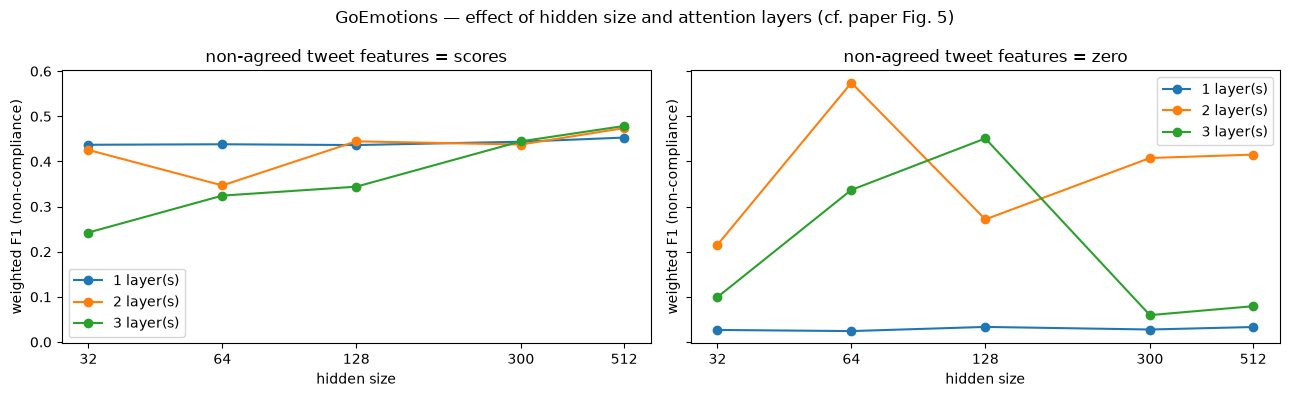

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, na in zip(axes, CFG['grid']['nonagreed']):
    s = grid[(grid.dataset == 'GoEmotions') & (grid['agg'] == 'attention') & (grid.nonagreed == na)]
    for L, ss in s.groupby('layers'):
        ax.plot(ss.hidden, ss.f1_NC, marker='o', label=f'{L} layer(s)')
    ax.set_xscale('log', base=2); ax.set_xticks(CFG['grid']['hidden']); ax.set_xticklabels(CFG['grid']['hidden'])
    ax.set_title(f'non-agreed tweet features = {na}'); ax.set_xlabel('hidden size'); ax.set_ylabel('weighted F1 (non-compliance)')
    ax.legend()
plt.suptitle('GoEmotions — effect of hidden size and attention layers (cf. paper Fig. 5)')
plt.tight_layout(); plt.savefig(os.path.join(RES_DIR, 'fig5_hyperparameters.png'), dpi=150); plt.show()

### 5.5 Tables 5–6 and Figs. 6–8: HGNN-Max / HGNN-Min vs the language models
Following the paper, **HGNN-Max** and **HGNN-Min** are the configurations whose predictions are most and least similar to RoBERTa-large. The paper picks them by this similarity, not by validation performance. To add a fair point of comparison, the table also includes **HGNN (val-selected)**: the attention configuration with the lowest validation loss, chosen without looking at gold labels.

Each cell shows **ours (paper)**.

In [15]:
sel_rows = []
for n in GRAPHS:
    gsub = grid[grid.dataset == n]
    for nm, r in (('HGNN-Max', gsub.loc[gsub.sim_roberta.idxmax()]), ('HGNN-Min', gsub.loc[gsub.sim_roberta.idxmin()]),
                  ('HGNN (val-selected)', gsub[gsub['agg'] == 'attention'].sort_values('val_loss').iloc[0])):
        sel_rows.append(dict(r) | {'model': nm})
sel = pd.DataFrame(sel_rows)
ours = pd.concat([base, sel], ignore_index=True)
ours.to_csv(os.path.join(RES_DIR, 'table5_6_ours.csv'), index=False)
print(sel[['dataset', 'model', 'agg', 'hidden', 'layers', 'nonagreed', 'sim_roberta']].to_string(index=False))

MODEL_ORDER = ['RoBERTa-large', 'DistilRoBERTa', 'DistilRoBERTa-v2', 'HGNN-Max', 'HGNN-Min', 'HGNN (val-selected)', RULE]
def side_by_side(metrics):
    o = ours.set_index(['dataset', 'model']); p = PAPER.set_index(['dataset', 'model'])
    cols = [f'{m}_{s}' for m in metrics for s in ('C', 'NC', 'T')]
    out = pd.DataFrame(index=pd.MultiIndex.from_product([list(GRAPHS), MODEL_ORDER]), columns=cols)
    for idx in out.index:
        for c in cols:
            ov = o.loc[idx, c] if idx in o.index else np.nan
            pv = p.loc[idx, c] if idx in p.index else np.nan
            out.loc[idx, c] = f'{ov:.3f}' + (f' ({pv:.3f})' if not np.isnan(pv) else '')
    return out

t5 = side_by_side(['acc', 'f1']); t6 = side_by_side(['precision', 'recall'])
t5.to_csv(os.path.join(RES_DIR, 'table5_side_by_side.csv')); t6.to_csv(os.path.join(RES_DIR, 'table6_side_by_side.csv'))
print('\nTable 5 — accuracy and F1:  ours (paper)')
display(t5)

   dataset               model       agg  hidden  layers nonagreed  sim_roberta
GoEmotions            HGNN-Max      mean      32       3      zero     0.795168
GoEmotions            HGNN-Min attention     512       2    scores     0.732045
GoEmotions HGNN (val-selected) attention     300       3      zero     0.750767
   Friends            HGNN-Max      mean      32       3      zero     0.796011
   Friends            HGNN-Min      mean      64       1    scores     0.729605
   Friends HGNN (val-selected) attention     128       3    scores     0.739238
       TEC            HGNN-Max      mean      32       1      zero     0.753171
       TEC            HGNN-Min attention     512       1    scores     0.677593
       TEC HGNN (val-selected) attention     512       1      zero     0.714123

Table 5 — accuracy and F1:  ours (paper)


acc_C         acc_NC          acc_T           f1_C          f1_NC           f1_T
GoEmotions RoBERTa-large             0.713 (0.731)  0.360 (0.370)  0.617 (0.636)  0.737 (0.753)  0.427 (0.434)  0.653 (0.670)
           DistilRoBERTa             0.713 (0.731)  0.384 (0.382)  0.623 (0.639)  0.737 (0.753)  0.462 (0.454)  0.661 (0.675)
           DistilRoBERTa-v2          0.703 (0.711)  0.556 (0.551)  0.663 (0.669)  0.718 (0.723)  0.601 (0.589)  0.684 (0.686)
           HGNN-Max                  0.713 (0.720)  0.536 (0.530)  0.665 (0.671)  0.737 (0.742)  0.565 (0.568)  0.696 (0.697)
           HGNN-Min                  0.714 (0.758)  0.397 (0.677)  0.627 (0.737)  0.738 (0.766)  0.474 (0.624)  0.664 (0.738)
           HGNN (val-selected)               0.713          0.052          0.533          0.737          0.060          0.598
           Rule: disagree → neutral          0.713          0.759          0.726          0.737          0.655          0.740
Friends    RoBERTa-large             0.724 (0.703)  0.459 (0.458)  0.650 (0.630)  0.732 (0.714)  0.486 (0.491)  0.664 (0.647)
           DistilRoBERTa             0.724 (0.703)  0.308 (0.287)  0.608 (0.579)  0.732 (0.714)  0.351 (0.337)  0.628 (0.605)
           DistilRoBERTa-v2          0.877 (0.878)  0.829 (0.845)  0.864 (0.868)  0.877 (0.878)  0.829 (0.843)  0.863 (0.867)
           HGNN-Max                  0.724 (0.652)  0.413 (0.258)  0.637 (0.535)  0.732 (0.674)  0.374 (0.303)  0.647 (0.578)
           HGNN-Min                  0.724 (0.550)  0.324 (0.585)  0.612 (0.561)  0.732 (0.406)  0.368 (0.433)  0.632 (0.416)
           HGNN (val-selected)               0.724          0.299          0.606          0.732          0.344          0.626
           Rule: disagree → neutral          0.724          0.556          0.677          0.732          0.398          0.667
TEC        RoBERTa-large             0.430 (0.451)  0.323 (0.308)  0.394 (0.401)  0.482 (0.482)  0.353 (0.337)  0.440 (0.430)
           DistilRoBERTa             0.430 (0.451)  0.141 (0.171)  0.334 (0.353)  0.482 (0.482)  0.173 (0.199)  0.392 (0.391)
           DistilRoBERTa-v2          0.316 (0.353)  0.161 (0.187)  0.265 (0.295)  0.373 (0.392)  0.205 (0.221)  0.322 (0.336)
           HGNN-Max                  0.430 (0.438)  0.350 (0.255)  0.404 (0.374)  0.482 (0.471)  0.288 (0.266)  0.431 (0.408)
           HGNN-Min                  0.429 (0.480)  0.151 (0.354)  0.338 (0.436)  0.481 (0.491)  0.182 (0.345)  0.394 (0.443)
           HGNN (val-selected)               0.430          0.135          0.333          0.482          0.098          0.386
           Rule: disagree → neutral          0.430          0.000          0.288          0.482          0.000          0.376

In [16]:
print('Table 6 — precision and recall:  ours (paper)')
display(t6)

Table 6 — precision and recall:  ours (paper)


precision_C   precision_NC    precision_T       recall_C      recall_NC       recall_T
GoEmotions RoBERTa-large             0.816 (0.819)  0.709 (0.683)  0.781 (0.778)  0.713 (0.731)  0.360 (0.370)  0.617 (0.636)
           DistilRoBERTa             0.816 (0.819)  0.657 (0.636)  0.773 (0.772)  0.713 (0.731)  0.384 (0.382)  0.623 (0.639)
           DistilRoBERTa-v2          0.744 (0.745)  0.669 (0.648)  0.720 (0.717)  0.703 (0.711)  0.556 (0.551)  0.663 (0.669)
           HGNN-Max                  0.816 (0.796)  0.606 (0.620)  0.764 (0.751)  0.713 (0.720)  0.536 (0.530)  0.665 (0.671)
           HGNN-Min                  0.816 (0.787)  0.658 (0.636)  0.772 (0.752)  0.714 (0.758)  0.397 (0.677)  0.627 (0.737)
           HGNN (val-selected)               0.816          0.496          0.793          0.713          0.052          0.533
           Rule: disagree → neutral          0.816          0.577          0.766          0.713          0.759          0.726
Friends    RoBERTa-large             0.762 (0.761)  0.564 (0.603)  0.707 (0.712)  0.724 (0.703)  0.459 (0.458)  0.650 (0.630)
           DistilRoBERTa             0.762 (0.761)  0.486 (0.508)  0.690 (0.691)  0.724 (0.703)  0.308 (0.287)  0.608 (0.579)
           DistilRoBERTa-v2          0.877 (0.878)  0.831 (0.845)  0.864 (0.868)  0.877 (0.878)  0.829 (0.845)  0.864 (0.868)
           HGNN-Max                  0.762 (0.730)  0.360 (0.398)  0.672 (0.657)  0.724 (0.652)  0.413 (0.258)  0.637 (0.535)
           HGNN-Min                  0.762 (0.423)  0.494 (0.343)  0.689 (0.435)  0.724 (0.550)  0.324 (0.585)  0.612 (0.561)
           HGNN (val-selected)               0.762          0.497          0.689          0.724          0.299          0.606
           Rule: disagree → neutral          0.762          0.309          0.672          0.724          0.556          0.677
TEC        RoBERTa-large             0.569 (0.534)  0.410 (0.402)  0.518 (0.484)  0.430 (0.451)  0.323 (0.308)  0.394 (0.401)
           DistilRoBERTa             0.569 (0.534)  0.303 (0.288)  0.505 (0.463)  0.430 (0.451)  0.141 (0.171)  0.334 (0.353)
           DistilRoBERTa-v2          0.523 (0.480)  0.350 (0.332)  0.481 (0.438)  0.316 (0.353)  0.161 (0.187)  0.265 (0.295)
           HGNN-Max                  0.569 (0.524)  0.328 (0.370)  0.490 (0.480)  0.430 (0.438)  0.350 (0.255)  0.404 (0.374)
           HGNN-Min                  0.568 (0.512)  0.309 (0.348)  0.505 (0.454)  0.429 (0.480)  0.151 (0.354)  0.338 (0.436)
           HGNN (val-selected)               0.569          0.223          0.517          0.430          0.135          0.333
           Rule: disagree → neutral          0.569          0.000          0.566          0.430          0.000          0.288

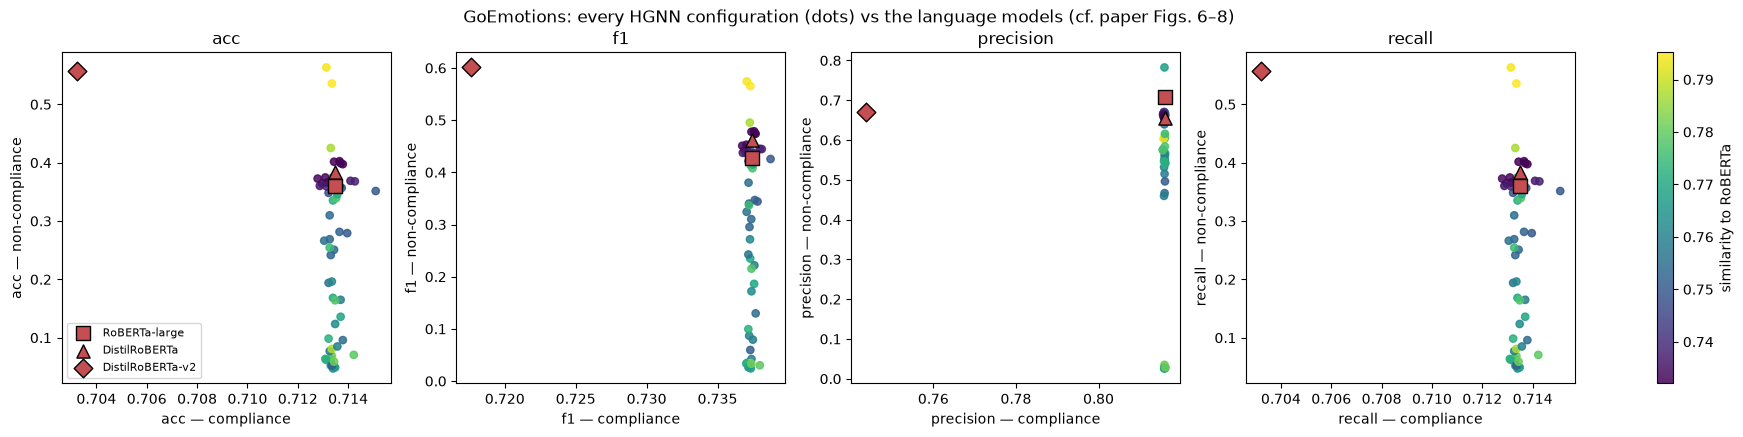

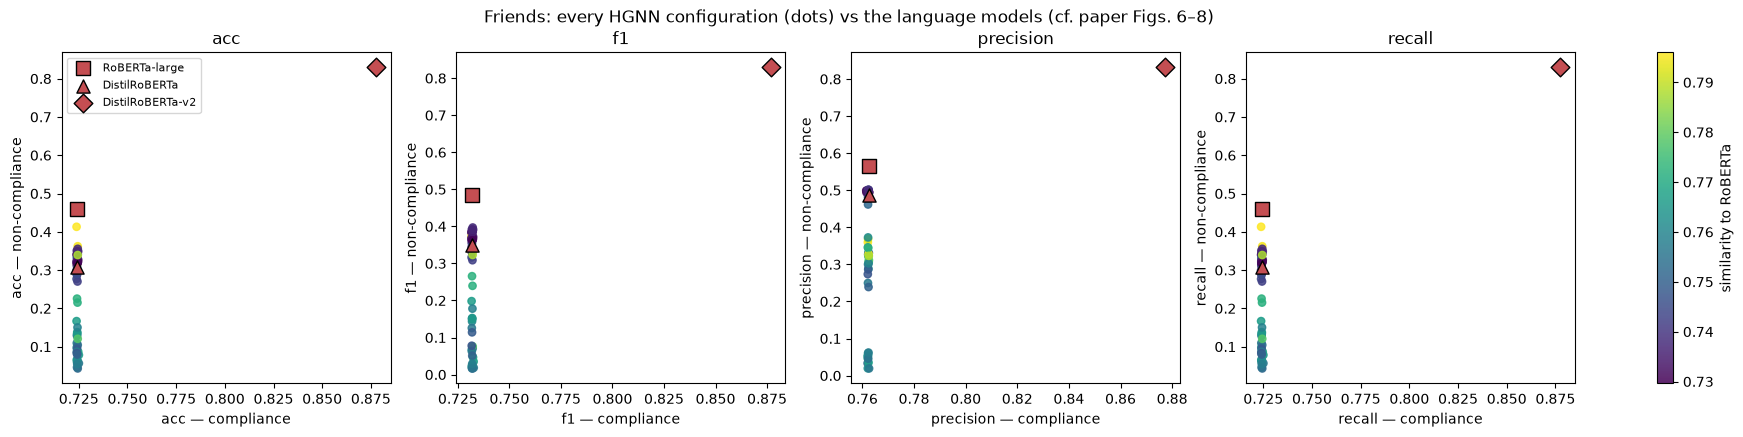

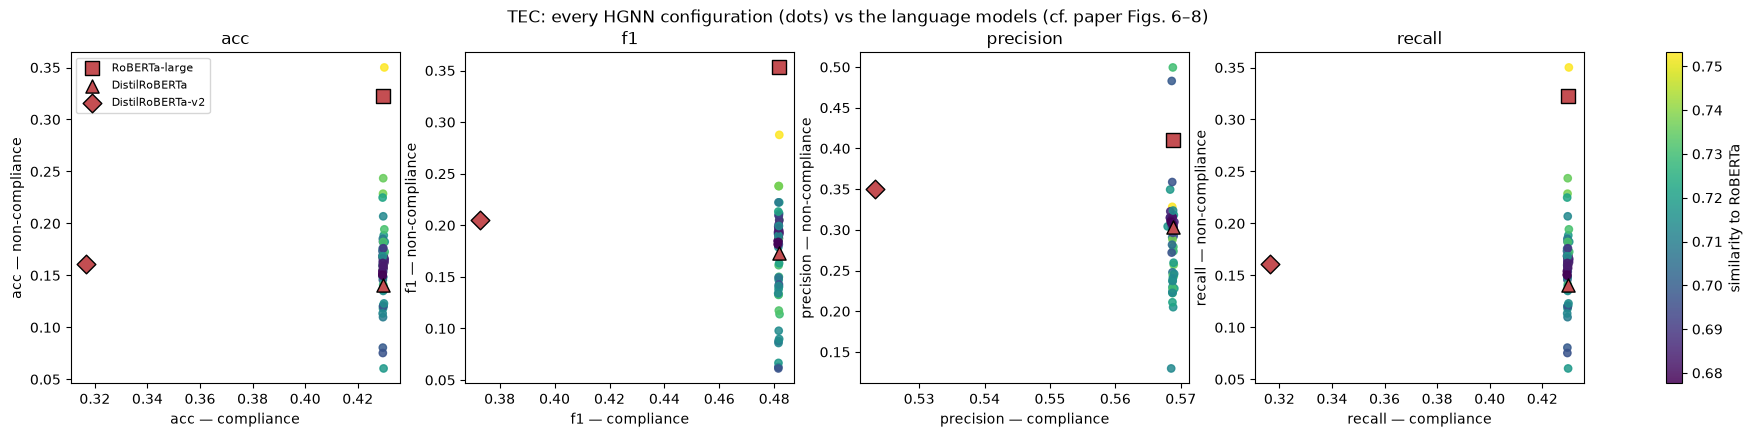

In [17]:
for n in GRAPHS:
    gsub = grid[grid.dataset == n]
    fig, axes = plt.subplots(1, 4, figsize=(21, 4.3))
    for ax, met in zip(axes, ['acc', 'f1', 'precision', 'recall']):
        sc = ax.scatter(gsub[f'{met}_C'], gsub[f'{met}_NC'], c=gsub.sim_roberta, cmap='viridis', s=28, alpha=.85)
        for nm, mk in (('RoBERTa-large', 's'), ('DistilRoBERTa', '^'), ('DistilRoBERTa-v2', 'D')):
            b = base[(base.dataset == n) & (base.model == nm)].iloc[0]
            ax.scatter(b[f'{met}_C'], b[f'{met}_NC'], marker=mk, s=90, color='#C44E52', edgecolor='k', label=nm)
        ax.set_xlabel(f'{met} — compliance'); ax.set_ylabel(f'{met} — non-compliance'); ax.set_title(met)
    axes[0].legend(fontsize=8)
    fig.colorbar(sc, ax=axes, label='similarity to RoBERTa', fraction=.02)
    fig.suptitle(f'{n}: every HGNN configuration (dots) vs the language models (cf. paper Figs. 6–8)')
    plt.savefig(os.path.join(RES_DIR, f'fig6-8_scatter_{n.lower()}.png'), dpi=150, bbox_inches='tight'); plt.show()

### 5.6 Table 7: statistical significance
The paper does not say what its t-tests are paired over. Here two HGNN configurations are each retrained with 10 seeds: the **HGNN-Max** configuration (the one that matches the paper) and the **val-selected** configuration. Each seed's total-set score is compared with each language-model baseline. The baselines are deterministic, so this is a one-sample t-test against the baseline value, which is equivalent to a paired test against a constant. The seed runs also show whether a single grid result is stable or a lucky draw.

In [18]:
SEED_CSV = os.path.join(RES_DIR, 'val_selected_seeds.csv')
seed_rows = pd.read_csv(SEED_CSV).to_dict('records') if os.path.exists(SEED_CSV) else []
SEL_CFG = {}
for (n, g), selection in itertools.product(GRAPHS.items(), ('HGNN-Max', 'HGNN (val-selected)')):
    r = sel[(sel.dataset == n) & (sel.model == selection)].iloc[0]
    cfg_ = (r['agg'], int(r.hidden), int(r.layers), r.nonagreed)
    SEL_CFG[(n, selection)] = str(cfg_)
    for s in range(CFG['n_seeds']):
        if any(x['dataset'] == n and x['seed'] == s and x['config'] == str(cfg_) for x in seed_rows):
            continue
        _, probs, _, _ = train_hgnn(g, *cfg_, seed=CFG['seed'] + s)
        seed_rows.append(dict(dataset=n, seed=s, config=str(cfg_), **evaluate(g, probs.argmax(1))))
        pd.DataFrame(seed_rows).to_csv(SEED_CSV, index=False)
seeds = pd.DataFrame(seed_rows)

stab = []
for (n, selection), c in SEL_CFG.items():
    v = seeds[(seeds.dataset == n) & (seeds.config == c)]
    single = sel[(sel.dataset == n) & (sel.model == selection)].iloc[0]
    stab.append(dict(dataset=n, selection=selection, config=c, **{f'{m} grid run': single[m] for m in ('acc_NC', 'f1_NC', 'acc_T')},
                     **{f'{m} seeds mean±std': f"{v[m].mean():.3f} ± {v[m].std(ddof=1):.3f}" for m in ('acc_NC', 'f1_NC', 'acc_T')},
                     **{'acc_NC seeds min–max': f"{v.acc_NC.min():.3f} – {v.acc_NC.max():.3f}"}))
stab = pd.DataFrame(stab)
stab.to_csv(os.path.join(RES_DIR, 'seed_stability.csv'), index=False)
print('Seed stability (10 seeds per configuration):')
display(stab.round(3))

t7 = []
for (n, selection), c in SEL_CFG.items():
    for met in ('acc', 'f1', 'recall'):
        v = seeds[(seeds.dataset == n) & (seeds.config == c)][f'{met}_T'].values
        for bm in ('RoBERTa-large', 'DistilRoBERTa', 'DistilRoBERTa-v2'):
            b = base[(base.dataset == n) & (base.model == bm)][f'{met}_T'].iloc[0]
            res_ = stats.ttest_1samp(v, b)
            t7.append(dict(selection=selection, metric=met, dataset=n, baseline=bm, hgnn_mean=v.mean(), hgnn_std=v.std(ddof=1),
                           baseline_value=b, t=res_.statistic, p=res_.pvalue))
t7 = pd.DataFrame(t7).merge(PAPER_T7, on=['metric', 'dataset'], how='left')
t7['HGNN better & p<0.05'] = (t7.t > 0) & (t7.p < 0.05)
t7.to_csv(os.path.join(RES_DIR, 'table7_ttests.csv'), index=False)
print('Table 7 replication — total-set metrics, HGNN seeds vs each baseline:')
t7.round(4)

Seed stability (10 seeds per configuration):


,dataset,selection,config,acc_NC grid run,f1_NC grid run,acc_T grid run,acc_NC seeds mean±std,f1_NC seeds mean±std,acc_T seeds mean±std,acc_NC seeds min–max
0,GoEmotions,HGNN-Max,"('mean', 32, 3, 'zero')",0.536,0.565,0.665,0.344 ± 0.228,0.365 ± 0.240,0.612 ± 0.062,0.048 – 0.611
1,GoEmotions,HGNN (val-selected),"('attention', 300, 3, 'zero')",0.052,0.060,0.533,0.057 ± 0.039,0.055 ± 0.061,0.534 ± 0.011,0.030 – 0.157
2,Friends,HGNN-Max,"('mean', 32, 3, 'zero')",0.413,0.374,0.637,0.279 ± 0.133,0.254 ± 0.137,0.600 ± 0.037,0.076 – 0.414
3,Friends,HGNN (val-selected),"('attention', 128, 3, 'scores')",0.299,0.344,0.606,0.301 ± 0.007,0.345 ± 0.007,0.606 ± 0.002,0.294 – 0.313
4,TEC,HGNN-Max,"('mean', 32, 1, 'zero')",0.350,0.288,0.404,0.178 ± 0.098,0.127 ± 0.080,0.347 ± 0.032,0.038 – 0.349
5,TEC,HGNN (val-selected),"('attention', 512, 1, 'zero')",0.135,0.098,0.333,0.100 ± 0.020,0.073 ± 0.017,0.321 ± 0.006,0.073 – 0.135


Table 7 replication — total-set metrics, HGNN seeds vs each baseline:


,selection,metric,dataset,baseline,hgnn_mean,hgnn_std,baseline_value,t,p,t (paper),p (paper),HGNN better & p<0.05
0,HGNN-Max,acc,GoEmotions,RoBERTa-large,0.6123,0.0623,0.6169,-0.2317,0.8220,4.73,0.0004,False
1,HGNN-Max,acc,GoEmotions,DistilRoBERTa,0.6123,0.0623,0.6233,-0.5557,0.5919,4.73,0.0004,False
2,HGNN-Max,acc,GoEmotions,DistilRoBERTa-v2,0.6123,0.0623,0.6630,-2.5723,0.0301,4.73,0.0004,False
3,HGNN-Max,f1,GoEmotions,RoBERTa-large,0.6516,0.0502,0.6531,-0.0985,0.9237,3.45,0.0015,False
4,HGNN-Max,f1,GoEmotions,DistilRoBERTa,0.6516,0.0502,0.6611,-0.6007,0.5629,3.45,0.0015,False
5,HGNN-Max,f1,GoEmotions,DistilRoBERTa-v2,0.6516,0.0502,0.6838,-2.0264,0.0734,3.45,0.0015,False
6,HGNN-Max,recall,GoEmotions,RoBERTa-large,0.6123,0.0623,0.6169,-0.2317,0.8220,3.98,0.0008,False
7,HGNN-Max,recall,GoEmotions,DistilRoBERTa,0.6123,0.0623,0.6233,-0.5557,0.5919,3.98,0.0008,False
8,HGNN-Max,recall,GoEmotions,DistilRoBERTa-v2,0.6123,0.0623,0.6630,-2.5723,0.0301,3.98,0.0008,False
9,HGNN (val-selected),acc,GoEmotions,RoBERTa-large,0.5343,0.0112,0.6169,-23.3282,0.0000,4.73,0.0004,False


### 5.7 Learned semantic-attention weights (val-selected attention model, GoEmotions)

In [19]:
g = GRAPHS['GoEmotions']
r = sel[(sel.dataset == 'GoEmotions') & (sel.model == 'HGNN (val-selected)')].iloc[0]
model, probs, _, _ = train_hgnn(g, r['agg'], int(r.hidden), int(r.layers), r.nonagreed)
att = pd.DataFrame([dict(layer=i + 1, node=t, message=m, alpha=a) for i, L in enumerate(model.layers)
                    for t, (ms, al) in L.alpha.items() for m, a in zip(ms, al.tolist())])
att.to_csv(os.path.join(RES_DIR, 'attention_weights_goemotions.csv'), index=False)
att.round(3)

,layer,node,message,alpha
0,1,phrase,tweet→phrase,0.014
1,1,phrase,emotion→phrase,0.986
2,2,phrase,tweet→phrase,0.015
3,2,phrase,emotion→phrase,0.985
4,3,phrase,tweet→phrase,0.498
5,3,phrase,emotion→phrase,0.502


### 5.8 Where the HGNN changes the label on non-compliance posts (GoEmotions, HGNN-Min vs HGNN-Max)

In [20]:
for nm in ('HGNN-Max', 'HGNN-Min'):
    r = sel[(sel.dataset == 'GoEmotions') & (sel.model == nm)].iloc[0]
    pred = PREDS[('GoEmotions', r['agg'], int(r.hidden), int(r.layers), r.nonagreed)]
    m = ~GRAPHS['GoEmotions']['comp']
    dist = pd.Series(pred[m]).map(dict(enumerate(LABELS))).value_counts(normalize=True).reindex(LABELS).fillna(0)
    print(f'{nm} ({r["agg"]}, hidden={int(r.hidden)}, layers={int(r.layers)}, non-agreed={r.nonagreed}) — '
          f'predicted label share on non-compliance set:')
    print((100 * dist).round(1).to_string(), '\n')
gold_nc = pd.Series(GRAPHS['GoEmotions']['gold'][~GRAPHS['GoEmotions']['comp']]).map(dict(enumerate(LABELS)))
print('Gold label share on GoEmotions non-compliance set:')
print((100 * gold_nc.value_counts(normalize=True).reindex(LABELS).fillna(0)).round(1).to_string())

HGNN-Max (mean, hidden=32, layers=3, non-agreed=zero) — predicted label share on non-compliance set:
anger        7.9
disgust     10.1
fear         9.3
joy          2.3
neutral     66.8
sadness      1.4
surprise     2.1 

HGNN-Min (attention, hidden=512, layers=2, non-agreed=scores) — predicted label share on non-compliance set:
anger       11.1
disgust     15.9
fear         3.3
joy          8.2
neutral     40.1
sadness      8.2
surprise    13.2 

Gold label share on GoEmotions non-compliance set:
anger        5.6
disgust      2.6
fear         1.6
joy          7.3
neutral     75.9
sadness      4.7
surprise     2.3


## 6. Save predictions

In [21]:
for n, g in GRAPHS.items():
    out = g['d'][['clean', 'gold']].copy()
    out['compliant'] = g['comp']
    for m, k in (('roberta', 'lb'), ('distil', 'la'), ('distil_v2', 'v2')):
        out[m] = [LABELS[i] for i in g[k]]
    for nm in ('HGNN-Max', 'HGNN-Min', 'HGNN (val-selected)'):
        r = sel[(sel.dataset == n) & (sel.model == nm)].iloc[0]
        out[nm] = [LABELS[i] for i in PREDS[(n, r['agg'], int(r.hidden), int(r.layers), r.nonagreed)]]
    out['phrases'] = g['phrases'].map('; '.join)
    out.to_csv(os.path.join(RES_DIR, f'predictions_{n.lower()}.csv'), index=False)
print(sorted(os.listdir(RES_DIR)))

['attention_weights_goemotions.csv', 'fig5_hyperparameters.png', 'fig6-8_scatter_friends.png', 'fig6-8_scatter_goemotions.png', 'fig6-8_scatter_tec.png', 'fig_phrase_emotion_edges.png', 'grid_all_configs.csv', 'predictions_friends.csv', 'predictions_goemotions.csv', 'predictions_tec.csv', 'run_attempt1.log', 'seed_stability.csv', 'table1_datasets.csv', 'table3_aggregation.csv', 'table4_compliance.csv', 'table5_6_ours.csv', 'table5_side_by_side.csv', 'table6_side_by_side.csv', 'table7_ttests.csv', 'val_selected_seeds.csv']


## 7. Replication verdict

**Reproduced**
* **Datasets (Table 1):** Friends is identical (11,731 utterances, same counts per class). TEC has 21,051 tweets vs 21,047. GoEmotions has 31,621 posts vs 32,291; the paper does not describe its subset, and this is the closest reconstruction.
* **Compliance split (Table 4):** within 2 percentage points on all three datasets.
* **Language-model baselines (Tables 5–6):** RoBERTa-large, DistilRoBERTa and DistilRoBERTa-v2 are within about 0.02 of the paper in almost every cell, on all three datasets.
* **HGNN-Max on GoEmotions:** within 0.01 of the paper on every accuracy and F1 cell (ours .713 / .536 / .665 accuracy vs the paper's .720 / .530 / .671). On TEC, HGNN-Max is close, slightly above the paper.

**Not reproduced**
* **HGNN-Min**, the paper's best GoEmotions result (0.677 accuracy on non-compliance posts). Our least RoBERTa-like configuration reaches 0.397.
* **Table 3 (attention > mean):** across 30 matched configurations, attention − mean = +0.010 F1 (p = 0.70). Averaged over configurations, both are below the language models, not above them.
* **Table 7 (significant gains):** retrained over 10 seeds, no HGNN configuration is significantly better than RoBERTa-large or DistilRoBERTa on any dataset. The only significant wins are over the Friends-specific DistilRoBERTa-v2 on TEC.
* **Friends:** the paper's HGNN models score *below* the baselines even on the compliance set (0.652 and 0.550 vs 0.703), which means they lose accuracy on posts they were trained on. Ours stay at the baseline level.

**Why — two findings**
1. **Zero-feature configurations are unstable.** The paper's second option gives non-agreed tweets zero features (§2.2.3). The model never sees a zero-feature tweet during training, so its predictions for them are essentially arbitrary. Retrained with 10 seeds, the HGNN-Max configuration (mean, hidden 32, 3 layers, zero) reaches **0.344 ± 0.228** accuracy on GoEmotions non-compliance posts, ranging from 0.048 to 0.611. The grid run that matches the paper is one draw from this range. Validation loss cannot detect this, because every validation tweet is an agreed tweet. That is why the val-selected model collapses (0.05).
2. **The non-compliance set is mostly neutral.** In the GoEmotions non-compliance set, 75.9% of the gold labels are *neutral*. A rule with no training — *keep the agreed label, answer neutral on disagreement* — scores **0.759** accuracy on non-compliance posts and **0.740** total weighted F1. That is at or above the paper's best HGNN (0.677 and 0.738). Gains on the non-compliance set should therefore be judged against this rule, not only against the language models. (On TEC, which has no neutral class, the rule scores 0 on the non-compliance set.)

**What this means for Phase 3B (improving accuracy)**
* Train the model on inputs that look like the disagreed tweets it will be tested on. For example, randomly zero or mix the features of agreed tweets during training, so the model learns to use phrase evidence.
* Use all the evidence: both models' scores (concatenation), with DistilRoBERTa-v2 as a third opinion.
* Choose models with a validation set that resembles the disagreement set, not only agreed tweets.
* Always report the "disagree → neutral" rule and RoBERTa-large as the bars to beat, with multiple seeds.